In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("../data/ethiopia.csv")

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [2]:
# Replace -999
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58
...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64


In [3]:
# Create DATE column
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

In [4]:
# Add Month
df["Month"] = df["DATE"].dt.month


In [5]:
# Add Country column
df["Country"] = "Ethiopia"

In [6]:
df.duplicated().sum()

np.int64(0)

No duplicate rows found

In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


- Average temperature (T2M) is around 16.07°C, indicating a moderate climate overall.
- Maximum temperatures (T2M_MAX) reach about 30.93°C, while the average daily high is around 23.2°C.
- Precipitation (PRECTOTCORR) is highly variable, ranging from 0 mm to ~82.3 mm, which highlights significant rainfall spikes.
- Humidity (RH2M) ranges widely (from 14.4% to 91.9%) → this suggests distinct seasonal changes between dry and wet periods.
- Wind Speed (WS2M) is generally low to moderate, averaging around 1.98 m/s.

In [8]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
DATE           0
Month          0
Country        0
dtype: int64

- Dataset has negligible missing values (<1%)
- Forward fill was applied for consistency

In [9]:
(df.isna().sum() / len(df)) * 100

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
DATE           0.0
Month          0.0
Country        0.0
dtype: float64

In [10]:
from scipy import stats

z_scores = np.abs(stats.zscore(df[[
    "T2M", "T2M_MAX", "T2M_MIN", 
    "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"
]].dropna()))

outliers = (z_scores > 3).sum()
outliers

np.int64(137)

- 137 outliers detected using Z-score > 3
- Outliers retained because they may represent extreme climate events

In [11]:
df = df.ffill()

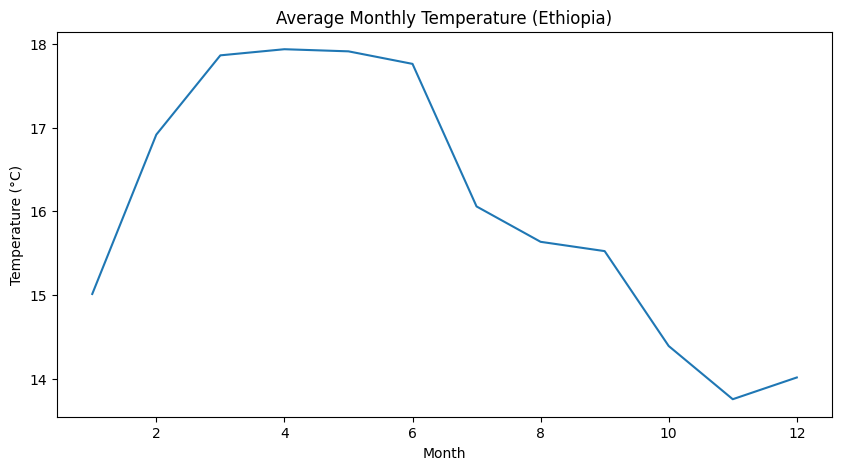

In [12]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(kind="line", figsize=(10,5))
plt.title("Average Monthly Temperature (Ethiopia)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

- Highest temprature occur around March-May
- Lowest temprature occur around  Novmberr

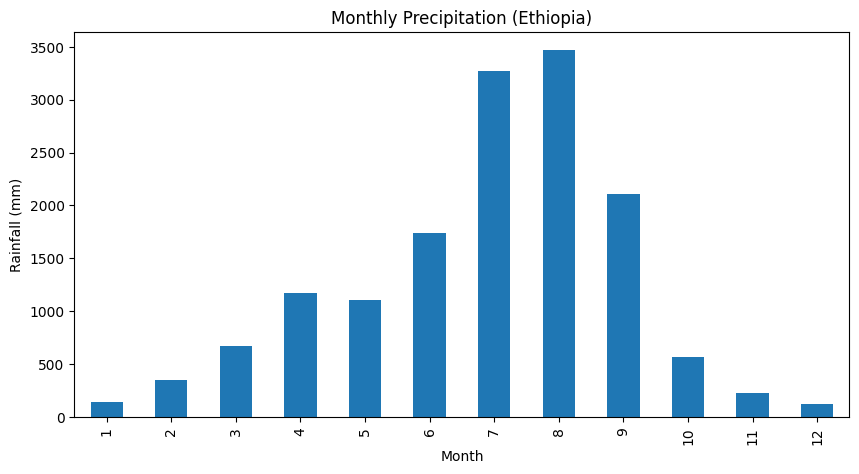

In [13]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar", figsize=(10,5))
plt.title("Monthly Precipitation (Ethiopia)")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.show()

- Rainfall peaks in July–Augest
- Less rainfall on Decemeber-January

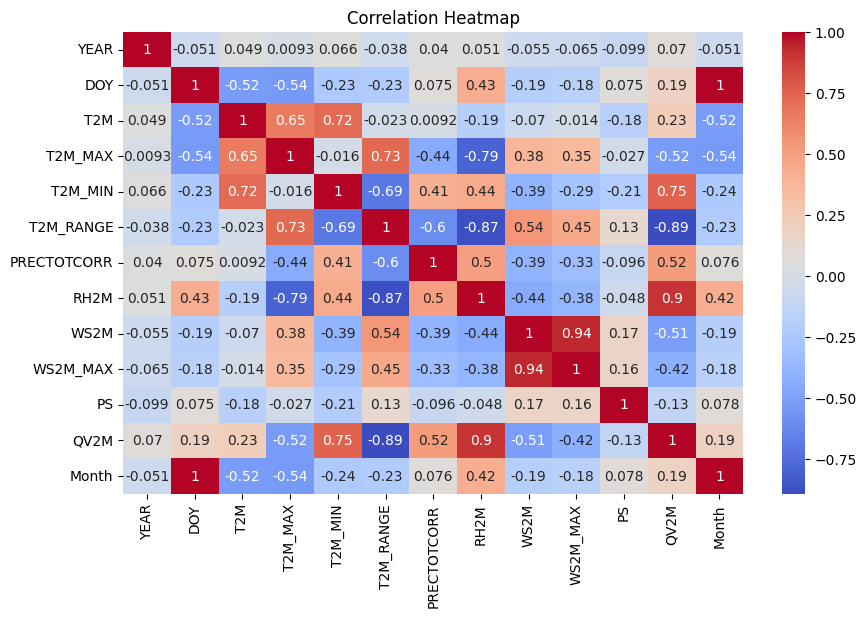

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

T2M vs T2M_MAX → strong positive
T2M vs RH2M → negative (hot = dry)

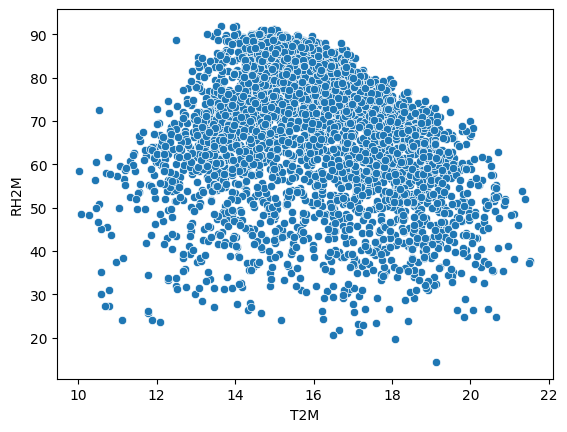

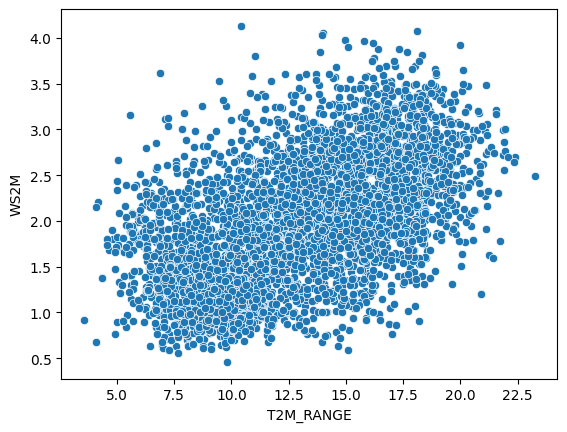

In [15]:
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.show()

sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.show()

- T2M vs. RH2M: As average temperature increases, humidity generally decreases, indicating a typical inverse relationship between heat and moisture.
- T2M_RANGE vs. WS2M: A clear positive correlation shows that wind speeds tend to increase on days with a larger gap between maximum and minimum temperatures.

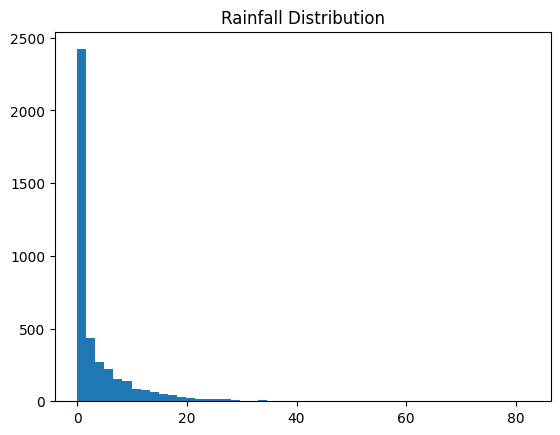

In [16]:
plt.hist(df["PRECTOTCORR"], bins=50)
plt.title("Rainfall Distribution")
plt.show()

- few high values and many low vlaues

In [17]:
df.to_csv("../data/ethiopia_clean.csv", index=False)